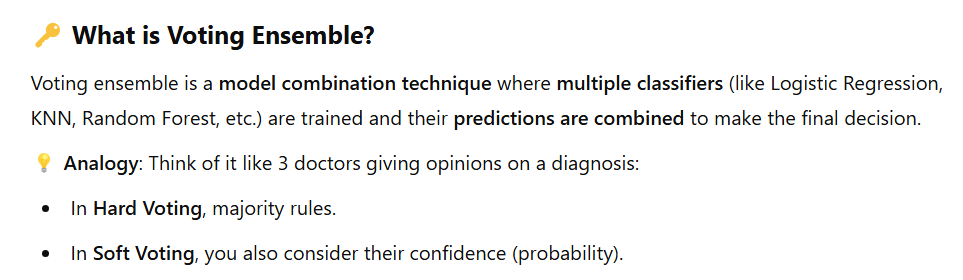

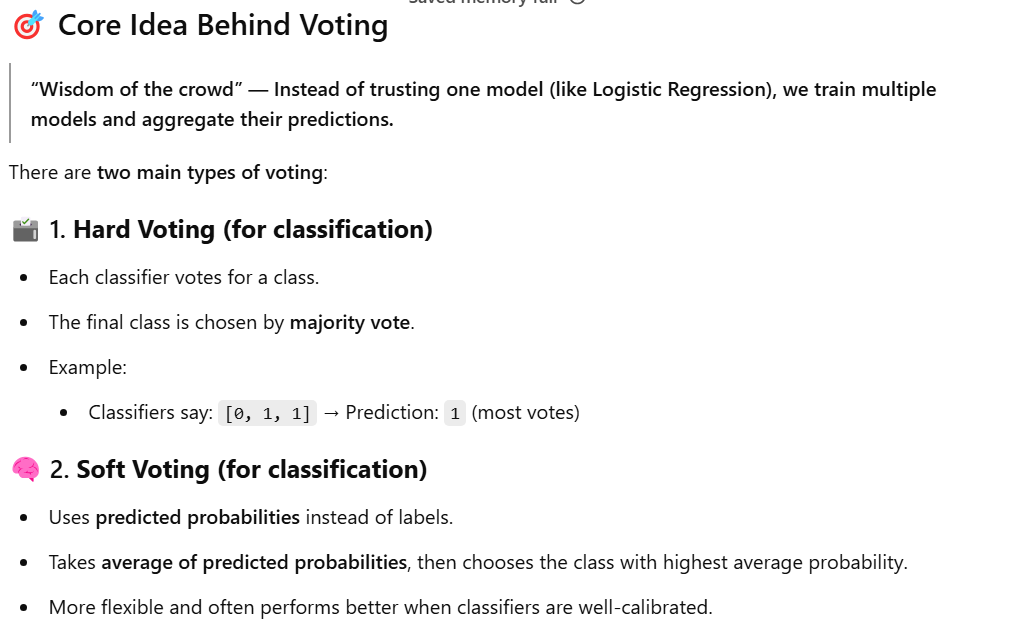

In [ ]:
VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('knn', clf3)],
                 voting='hard' or 'soft',
                 weights=[1,2,1],
                 n_jobs=-1,
                 flatten_transform=True)


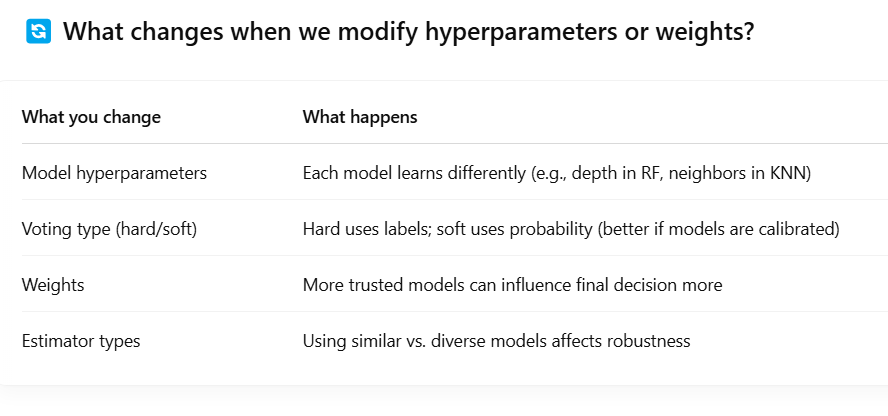

In [ ]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

# individual accuracy
cross_val_score(clf1, X, y) → 0.81
cross_val_score(clf2, X, y) → 0.73
cross_val_score(clf3, X, y) → 0.75

# Voting Ensemble
vc = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('knn', clf3)], voting='hard')
cross_val_score(vc, X, y) → 0.77

# With weights
vc = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('knn', clf3)], voting='soft', weights=[3,1,1])
cross_val_score(vc, X, y) → 0.80


In [ ]:
from sklearn.ensemble import VotingRegressor
reg1 = LinearRegression()
reg2 = DecisionTreeRegressor()
reg3 = KNeighborsRegressor()

ereg = VotingRegressor(estimators=[('lr', reg1), ('dt', reg2), ('knn', reg3)])#it takes list of tuples in estimators
ereg.fit(X_train, y_train)
ereg.predict(X_test)


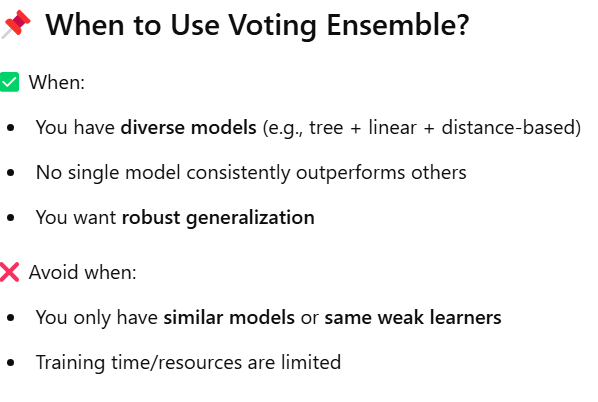

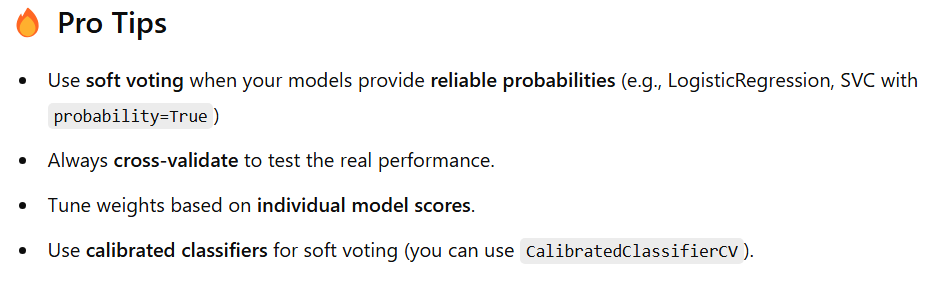

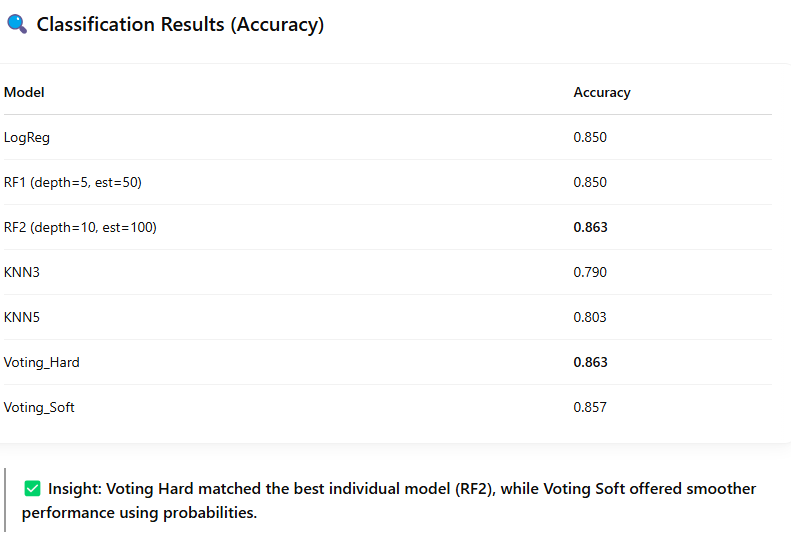

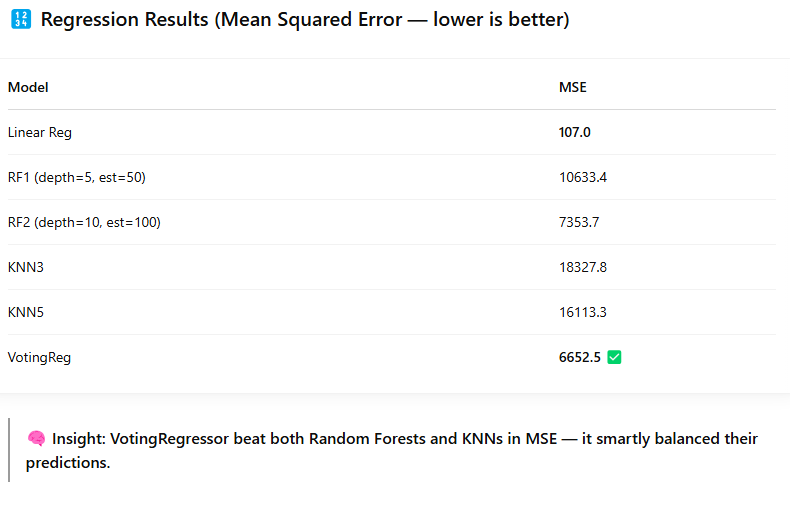

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

# Load the Iris dataset from sklearn
iris = load_iris()

# Convert to a pandas DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['Species'] = iris.target

# Encode 'Species' column (already encoded in `iris.target`, but we'll keep this step for clarity)
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

# Prepare features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except 'Species'
y = df.iloc[:, -1]   # 'Species' column

# Define individual classifiers
clf1 = LogisticRegression(max_iter=200, random_state=42)
clf2 = RandomForestClassifier(random_state=42)
clf3 = KNeighborsClassifier()
clf4 = SVC(probability=True, kernel='linear', random_state=42)

# List of estimators for Voting Classifier
estimators = [('lr', clf1), ('rf', clf2), ('knn', clf3), ('svc', clf4)]

# Evaluate individual classifiers
print("Individual Classifier Performance:")
for name, estimator in estimators:
    scores = cross_val_score(estimator, X, y, cv=10, scoring='accuracy')
    print(f"{name}: {np.round(np.mean(scores), 2)}")

# Hard Voting Classifier
print("\nHard Voting Classifier Performance:")
hard_voting_clf = VotingClassifier(estimators=estimators, voting='hard')
hard_scores = cross_val_score(hard_voting_clf, X, y, cv=10, scoring='accuracy')
print(f"Hard Voting Accuracy: {np.round(np.mean(hard_scores), 2)}")

# Soft Voting Classifier
print("\nSoft Voting Classifier Performance:")
soft_voting_clf = VotingClassifier(estimators=estimators, voting='soft')
soft_scores = cross_val_score(soft_voting_clf, X, y, cv=10, scoring='accuracy')
print(f"Soft Voting Accuracy: {np.round(np.mean(soft_scores), 2)}")

# Weighted Voting Classifier (Grid Search for Best Weights)
print("\nWeighted Voting Classifier Performance:")
best_accuracy = 0
best_weights = None
for i in range(1, 4):  # Weight range for clf1
    for j in range(1, 4):  # Weight range for clf2
        for k in range(1, 4):  # Weight range for clf3
            for l in range(1, 4):  # Weight range for clf4
                weights = [i, j, k, l]
                weighted_voting_clf = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
                scores = cross_val_score(weighted_voting_clf, X, y, cv=10, scoring='accuracy')
                accuracy = np.mean(scores)
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_weights = weights

print(f"Best Weighted Voting Accuracy: {np.round(best_accuracy, 2)} with weights: {best_weights}")

Individual Classifier Performance:
lr: 0.97
rf: 0.96
knn: 0.97
svc: 0.97

Hard Voting Classifier Performance:
Hard Voting Accuracy: 0.97

Soft Voting Classifier Performance:
Soft Voting Accuracy: 0.97

Weighted Voting Classifier Performance:
Best Weighted Voting Accuracy: 0.97 with weights: [3, 1, 1, 1]


###1. Classifiers of Same Algo


In [8]:
from sklearn.svm import SVC


In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [10]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.93


##2. Regressor

In [ ]:
# Import necessary libraries
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
def load_data():
    data = fetch_california_housing()
    X = data.data
    y = data.target
    return X, y

# Main function
def main():
    # Load and split data
    X, y = load_data()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define individual regressors
    lr = LinearRegression()
    dt = DecisionTreeRegressor(max_depth=5, random_state=42)
    svr = SVR(kernel='rbf', C=1.0)

    # Create Voting Regressor
    voting_reg = VotingRegressor(estimators=[
        ('lr', lr),
        ('dt', dt),
        ('svr', svr)
    ])

    # Train and evaluate individual regressors
    print("Individual Regressor Performance (MSE):")
    for name, model in [('lr', lr), ('dt', dt), ('svr', svr)]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        print(f"{name}: {np.round(mse, 2)}")

    # Train and evaluate Voting Regressor
    voting_reg.fit(X_train, y_train)
    y_pred_voting = voting_reg.predict(X_test)
    mse_voting = mean_squared_error(y_test, y_pred_voting)
    r2_voting = r2_score(y_test, y_pred_voting)

    print("\nVoting Regressor Performance:")
    print(f"Mean Squared Error (MSE): {np.round(mse_voting, 2)}")
    print(f"R² Score: {np.round(r2_voting, 2)}")

# Run the script
if __name__ == "__main__":
    main()

Individual Regressor Performance (MSE):
lr: 0.56
dt: 0.52
svr: 1.33
